In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("_________________________TASK 1______________________________________")
df = pd.read_csv("Housing.csv")
df.head(10)
print("Rows and Columns:", df.shape)
print("------------COLUMN NAMES--------------")
print(df.columns)
print("-----------TARGET COLUMN-----------")
target = "price"
features = df.drop("price", axis=1)
print("Target Column:", target)
print("\n---------FEATURE COLUMNS-----------")
print("Feature Columns:")
print(features.columns)
print("\n------------MISSING VALUES-----------------")
df.isnull().sum()

_________________________TASK 1______________________________________
Rows and Columns: (545, 13)
------------COLUMN NAMES--------------
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')
-----------TARGET COLUMN-----------
Target Column: price

---------FEATURE COLUMNS-----------
Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')

------------MISSING VALUES-----------------


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [48]:
print("_________________________TASK -2___________________________")
df.isnull().sum()
print("-----------------handling missing values-------------------")
df = df.dropna()
print(df)
df.fillna(df.median(numeric_only=True), inplace=True)
print("----------------Duplicate rows-------------------------")
print("Duplicate rows:", df.duplicated().sum())
print("-----------------remove duplicate----------------------")
df = df.drop_duplicates()
print(df)
print("----------categorical columns to numerical--------------")
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
df.head()
df.info()
print("---------------meaningful columns-------------------------")
print(df.columns)
X = df.drop("price", axis=1)
y = df["price"]

_________________________TASK -2___________________________
-----------------handling missing values-------------------
        price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0    13300000  7420         4          2        3        2          True   
1    12250000  8960         4          4        4        3          True   
2    12250000  9960         3          2        2        2          True   
3    12215000  7500         4          2        2        3          True   
4    11410000  7420         4          1        2        2          True   
..        ...   ...       ...        ...      ...      ...           ...   
540   1820000  3000         2          1        1        2          True   
541   1767150  2400         3          1        1        0         False   
542   1750000  3620         2          1        1        0          True   
543   1750000  2910         3          1        1        0         False   
544   1750000  3850         3          1    

In [62]:
print("--------------------TASK-3----------------------")
X = df.drop("price", axis=1)
y = df["price"]
print("---------------------split(80/20)---------------------------")
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("----------------------Linear regression----------------------------")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Trained successfully")
print("-----------------Evaluation of linear regression-------------------------")
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)
print("-----------------Random forest------------------------")
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)
print("----------------comparing both the model---------------------")
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})
comparison

--------------------TASK-3----------------------
---------------------split(80/20)---------------------------
Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)
----------------------Linear regression----------------------------
Trained successfully
-----------------Evaluation of linear regression-------------------------
Linear Regression Results
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R²  : 0.6529242642153184
-----------------Random forest------------------------
Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R²  : 0.611918531405699
----------------comparing both the model---------------------


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


------------------------TASK -4-------------------------
HISTOGRAM


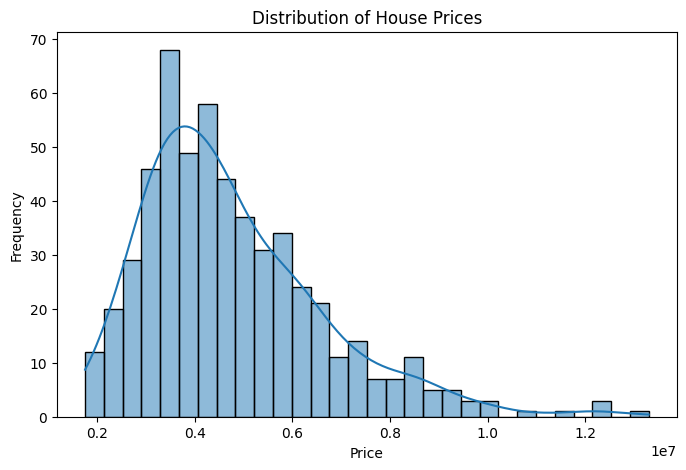

HEATMAP


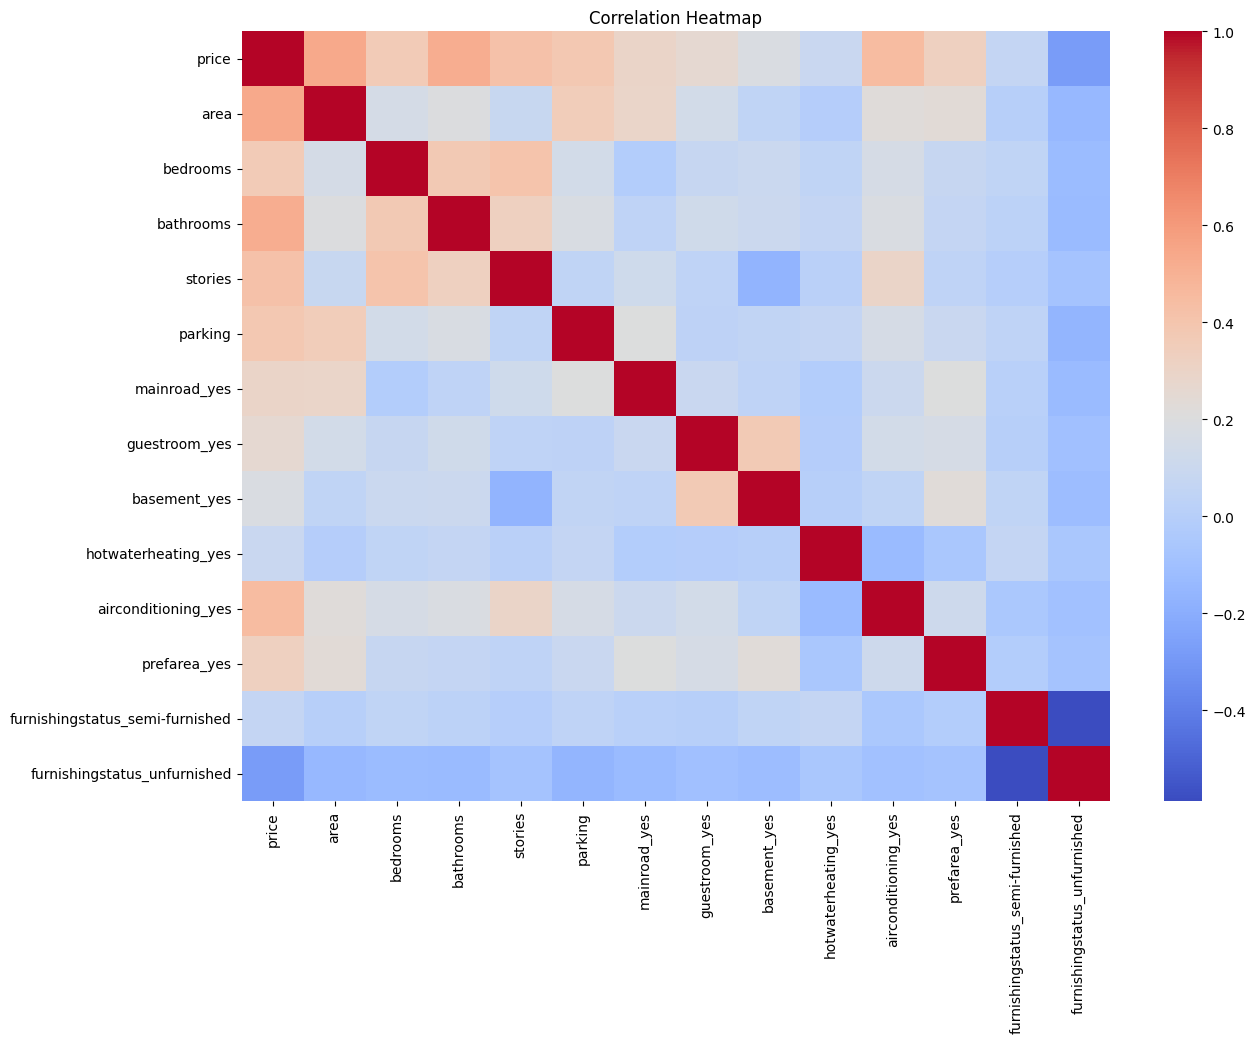

Actual vs Predicated


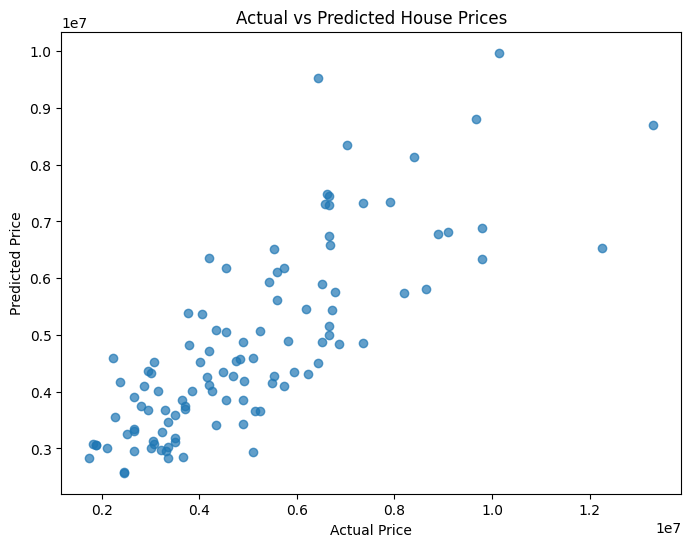

Alternative


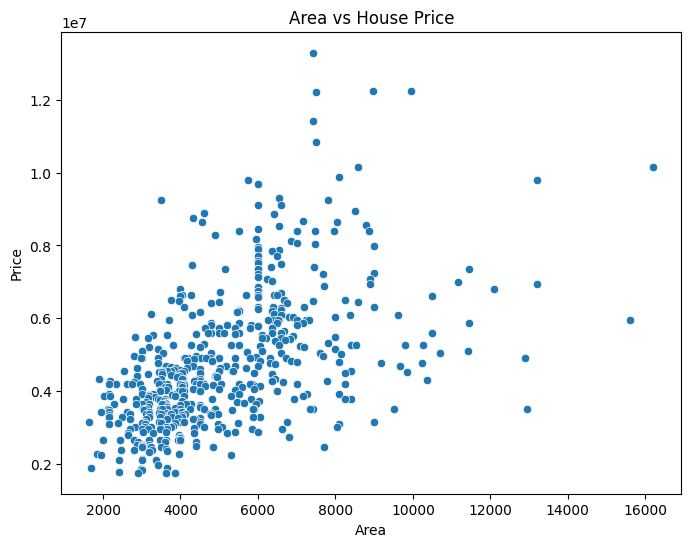

In [69]:
print("------------------------TASK -4-------------------------")
plt.figure(figsize=(8,5))
sns.histplot(df['price'],bins=30,kde=True)
print("HISTOGRAM")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("price_distribution.png")
plt.show()
print("HEATMAP")
plt.figure(figsize=(14,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix,cmap='coolwarm',annot=False)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()
print("Actual vs Predicated")
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_rf,alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig("actual_vs_predicted.png")
plt.show()
print("Alternative")
plt.figure(figsize=(8,6))
sns.scatterplot(x='area',y='price',data=df)
plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.savefig("price_vs_area.png")
plt.show()

In [6]:
import os
import matplotlib.pyplot as plt
os.makedirs("charts", exist_ok=True)

print("Folder created successfully!")

print(os.listdir())
plt.savefig("charts/price_distribution.png")
plt.savefig("charts/correlation_heatmap.png")
plt.savefig("charts/actual_vs_predicted.png")

print(os.listdir("charts"))

Folder created successfully!
['.antigravity', '.cache', '.claude', '.claude.json', '.copilot', '.gemini', '.git', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.matplotlib', '.redhat', '.vscode', 'actual_vs_predicted.png', 'AppData', 'Application Data', 'charts', 'Contacts', 'Cookies', 'correlation_heatmap.png', 'Documents', 'Downloads', 'Favorites', 'go', 'HousePricePrediction_ChimeekhaA.ipynb', 'Housing.csv', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{7598124d-644b-11f0-b013-f83dc6ef22f7}.TxR.0.regtrans-ms', 'NTUSER.DAT{7598124d-644b-11f0-b013-f83dc6ef22f7}.TxR.1.regtrans-ms', 'NTUSER.DAT{7598124d-644b-11f0-b013-f83dc6ef22f7}.TxR.2.regtrans-ms', 'NTUSER.DAT{7598124d-644b-11f0-b013-f83dc6ef22f7}.TxR.blf', 'NTUSER.DAT{7598124e-644b-11f0-b013-f83dc6ef22f7}.TM.blf', 'NTUSER.DAT{7598124e-644b-11f0-b013-f83dc6ef22f7}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{7598124e-644b-11f0-

<Figure size 640x480 with 0 Axes>

In [ ]:
print

The house price prediction project was completed using Linear Regression and 
Random Forest Regressor models. 
    The analysis showed that features such as area, number of bathrooms, 
number of stories, parking availability, and air conditioning had the 
greatest influence on house prices. The Random Forest model achieved better 
performance and provided more accurate predictions than the Linear Regression model. 
    In simple terms, the model was able to estimate house prices reasonably well 
based on the available property features. One surprising observation was that amenities
and location-related factors significantly affected house prices in addition to the size 
of the house. Based on these findings, real estate businesses should focus on property size, 
facilities, and preferred locations when determining prices and making investment decisions.
